**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

**Import Data**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [4]:
df=pd.read_csv("advertising.csv")

# **EDA**

In [5]:
print(df.shape)

(200, 4)


In [6]:
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [8]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


**Independent And Dependent Variable**

In [9]:
Y=df['Sales'].values
X=df[['TV','Radio','Newspaper']].values

# **Visual EDA**

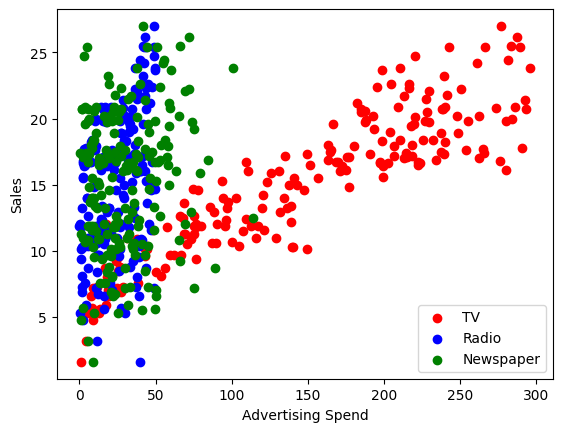

In [10]:
plt.scatter(df['TV'], df['Sales'], color='red', label='TV')
plt.scatter(df['Radio'], df['Sales'], color='blue', label='Radio')
plt.scatter(df['Newspaper'], df['Sales'], color='green', label='Newspaper')
plt.xlabel('Advertising Spend')
plt.ylabel('Sales')
plt.legend(loc=4)
plt.show()


In [11]:
print(X.shape)
print(Y.shape)

(200, 3)
(200,)


# **Train Test Split**

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=42)

In [13]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(140, 3)
(140,)
(60, 3)
(60,)


# **Mechanics Of Model**

In [14]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
lm.fit(X_train,Y_train)
Y_pred=lm.predict(X_test)

In [15]:
a=lm.coef_
b=lm.intercept_
print(a)
print(b)

[0.05358869 0.10270677 0.00793167]
4.743766701589685


In [16]:
'''TV:y=0.05358869*x+4.743766701589685
Radio:y=0.10270677*x+4.743766701589685
Newspaper:y=0.00793167*x+4.743766701589685'''

'TV:y=0.05358869*x+4.743766701589685\nRadio:y=0.10270677*x+4.743766701589685\nNewspaper:y=0.00793167*x+4.743766701589685'

In [17]:
lm.predict(X_test)[0:5]

array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836])

In [18]:
pred_train=lm.predict(X_train[0:5])
print(pred_train)

[21.11848606 16.98365454 12.88719008 10.146882   20.81051619]


# **Regression Metrics**

In [19]:
print("Y_test shape:", Y_test.shape)
print("Y_pred shape:", Y_pred.shape)


Y_test shape: (60,)
Y_pred shape: (60,)


In [20]:
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)
print("Length of Y_pred:", len(Y_pred))


X_test shape: (60, 3)
Y_test shape: (60,)
Length of Y_pred: 60


In [21]:
from sklearn.metrics import mean_squared_error
Y_test=np.ravel(Y_test)
Y_pred=np.ravel(Y_pred)
mse=mean_squared_error(Y_test, Y_pred)
rmse=np.sqrt(mse)
print("RMSE Value: {:.4f}".format(rmse))

RMSE Value: 1.5942


In [22]:
from sklearn.metrics import r2_score
print("r2 Score: {:.4f}".format(r2_score(Y_test,Y_pred)))

r2 Score: 0.9091


# **Interpretation**

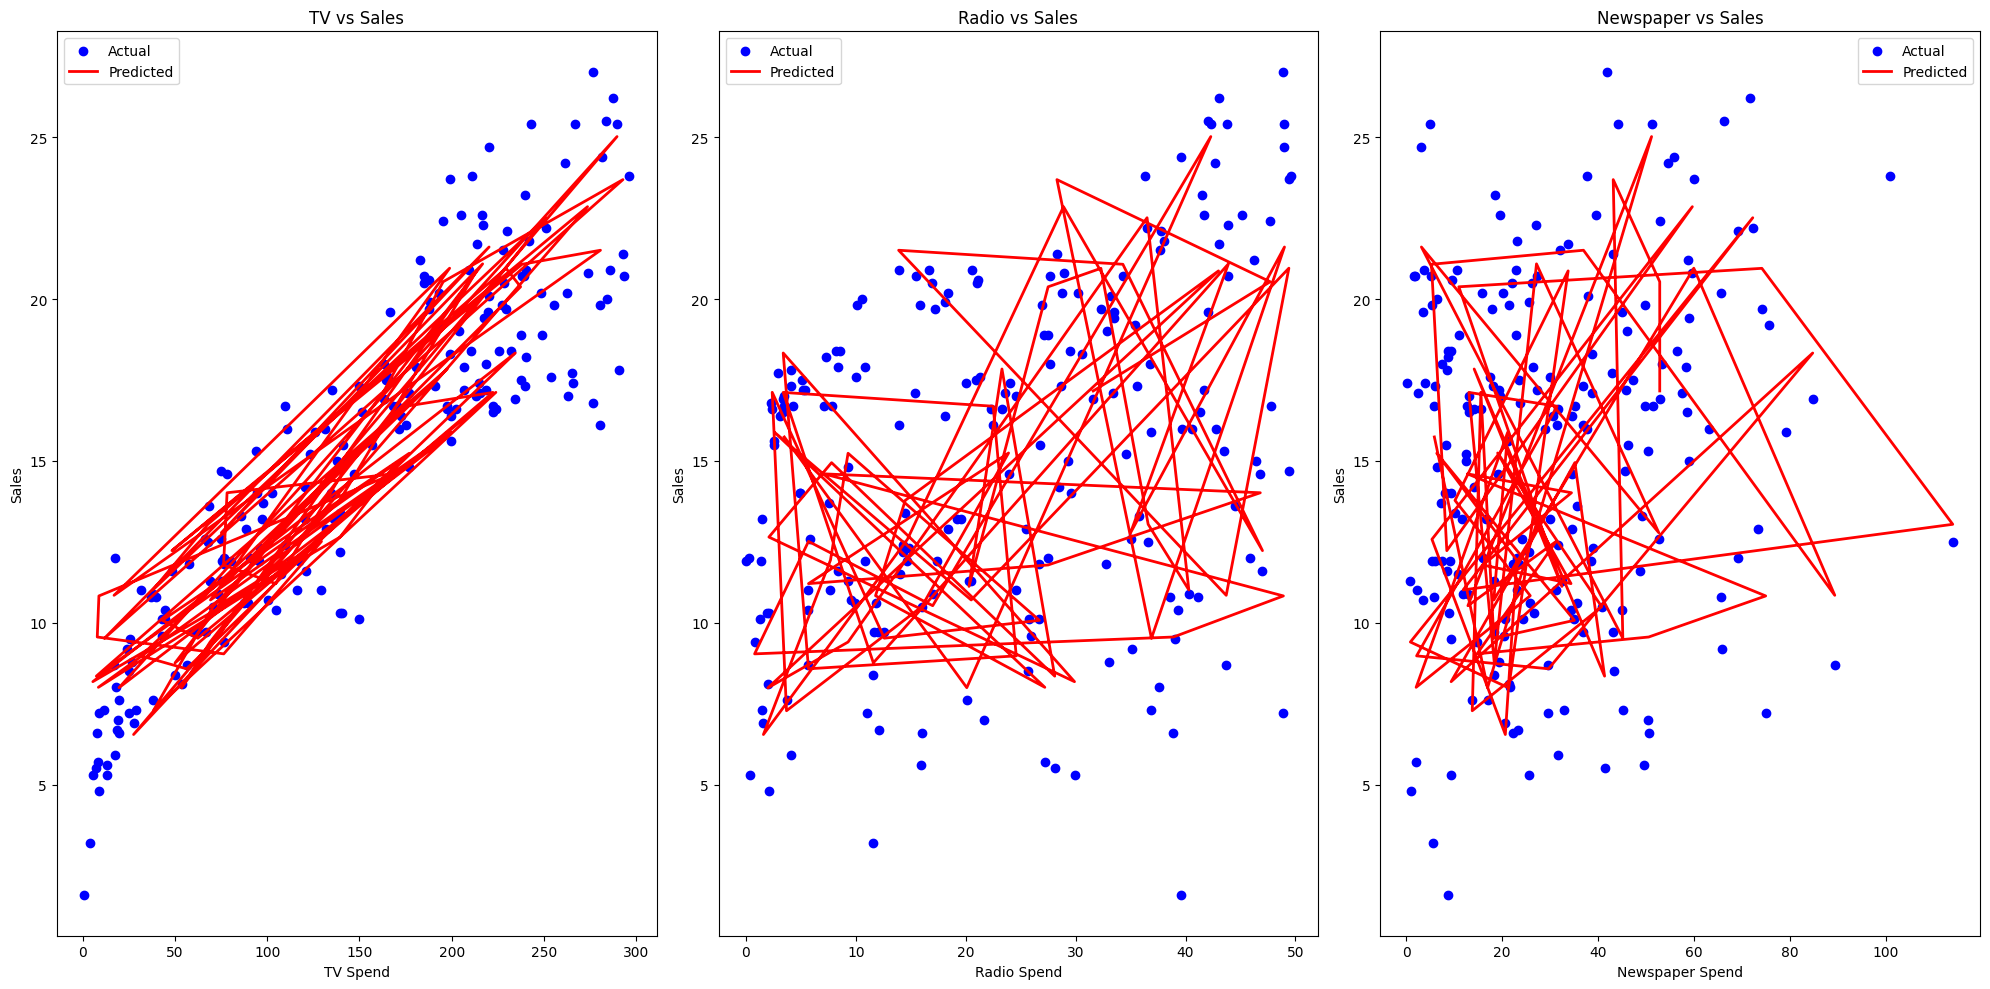

In [23]:
plt.figure(figsize=(20,10))
# TV vs Sales
plt.subplot(1,3,1)
plt.scatter(df['TV'],df['Sales'],color='blue',label='Actual')
plt.plot(X_test[:,0],Y_pred,color='red',linewidth=2,label='Predicted')
plt.xlabel('TV Spend')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.legend()

# Radio vs Sales
plt.subplot(1,3,2)
plt.scatter(df['Radio'],df['Sales'],color='blue',label='Actual')
plt.plot(X_test[:,1],Y_pred,color='red',linewidth=2,label='Predicted')
plt.xlabel('Radio Spend')
plt.ylabel('Sales')
plt.title('Radio vs Sales')
plt.legend()

# Newspaper vs Sales
plt.subplot(1,3,3)
plt.scatter(df['Newspaper'],df['Sales'],color='blue',label='Actual')
plt.plot(X_test[:,2],Y_pred,color='red',linewidth=2,label='Predicted')
plt.xlabel('Newspaper Spend')
plt.ylabel('Sales')
plt.title('Newspaper vs Sales')
plt.legend()
plt.tight_layout()
plt.show()


**Overfitting and underfitting**

In [24]:
print("Training set score:{:.4f}".format(lm.score(X_train,Y_train)))
print("Test set score:{:.4f}".format(lm.score(X_test,Y_test)))

Training set score:0.8920
Test set score:0.9091


In [25]:
import joblib
joblib.dump(lm,'lm_regressor.pkl')

['lm_regressor.pkl']